In [3]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import pandas as pd

import sys

sys.path.append("..")

from src.conformal_prediction.utils import compute_coverage, compute_volume_ellipsoid

In [4]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 20}
    plt.rc("font", **font)

In [5]:
set_style()

In [6]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params


def load_list_with_pickle(file_name):
    with open(file_name, "rb") as file:
        result = pickle.load(file)
    return result


def save_list_with_pickle(my_list, file_name):
    with open(file_name, "wb") as file:
        pickle.dump(my_list, file)

# Conformal prediction regions with fixed output covariance

In [7]:
index = 1
params_path = "params/n{}.json".format(index)
input_path = "results/prediction_regions/n{}/global/".format(index)

In [8]:
result = load_list_with_pickle(input_path + "result.pkl")

In [9]:
params = reader(params_path)

{'index': 1, 'pre_data': {'seed': 0, 'sample_size': 500, 'input_dimension': 2, 'output_dimension': 2, 'covariance_matrix': [[1.0, 0.5], [0.5, 1.0]], 'pert': 'gaussian', 'n_anchors': 2}, 'data': {'sample_size': 500, 'input_dimension': 2, 'output_dimension': 2, 'covariance_matrix': [[1.0, 0.5], [0.5, 1.0]], 'pert': 'gaussian', 'n_anchors': 2}, 'loss_name': 'log_cosh', 'loss_params': {'alpha': 1.0}, 'kernel': 'laplacian', 'kernel_max': 1.0, 'solver': 'Newton-CG', 'lams_number': 20, 'lam_min': 0.001, 'lam_max': 0.5, 'rep_number': 100, 'confidence_control_level': 0.1, 'regularization_values': [1e-06], 'neighbor_numbers': [20]}


In [10]:
rep_number = len(result["upper_prediction_regions"])
columns = ["coverage", "length", "time"]
conformal_predictors_names = ["OracleCP", "SplitCP", "GlobalEllipsoidCP"]
df_results = [{} for _ in params["regularization_values"]]
for df_result in df_results:
    for key in conformal_predictors_names:
        df_result[key] = pd.DataFrame(
            np.zeros((rep_number, len(columns))), columns=columns
        )

In [11]:
def record(new_output, prediction_region, time):
    return np.array(
        [
            np.float64(compute_coverage(prediction_region, new_output))
            .flatten()
            .item(),
            compute_volume_ellipsoid(
                prediction_region[-1], prediction_region[1]
            ).item(),
            time
        ],
        dtype=object,
    )

In [12]:
def transpose_dict_list(input, keys):
    keys_number = len(keys)
    input_size = len(input)
    batch_size = np.int64(input_size / keys_number)
    res = [
        {key: [input[iter * keys_number + index][key] for iter in range(batch_size)]}
        for index, key in enumerate(keys)
    ]
    return res

In [13]:
result["oracle_prediction_regions"] = transpose_dict_list(
    result["oracle_prediction_regions"], params["regularization_values"]
)
result["split_prediction_regions"] = transpose_dict_list(
    result["split_prediction_regions"], params["regularization_values"]
)
result["upper_prediction_regions"] = transpose_dict_list(
    result["upper_prediction_regions"], params["regularization_values"]
)

In [14]:
result["oracle_prediction_run_times"] = transpose_dict_list(
    result["oracle_prediction_run_times"], params["regularization_values"]
)
result["split_prediction_run_times"] = transpose_dict_list(
    result["split_prediction_run_times"], params["regularization_values"]
)
result["upper_prediction_run_times"] = transpose_dict_list(
    result["upper_prediction_run_times"], params["regularization_values"]
)

In [15]:
for iter in range(rep_number):
    for index, regularization in enumerate(params["regularization_values"]):
        df_results[index]["OracleCP"].iloc[iter] = record(
            result["new_outputs"][iter],
            result["oracle_prediction_regions"][index][regularization][iter],
            result["oracle_prediction_run_times"][index][regularization][iter]
            /result["oracle_prediction_run_times"][index][regularization][iter],
        )
        df_results[index]["SplitCP"].iloc[iter] = record(
            result["new_outputs"][iter],
            result["split_prediction_regions"][index][regularization][iter],
            result["split_prediction_run_times"][index][regularization][iter]
            /result["oracle_prediction_run_times"][index][regularization][iter],
        )
        df_results[index]["GlobalEllipsoidCP"].iloc[iter] = record(
            result["new_outputs"][iter],
            result["upper_prediction_regions"][index][regularization][iter],
            result["upper_prediction_run_times"][index][regularization][iter]/
            result["oracle_prediction_run_times"][index][regularization][iter],
        )

In [20]:
def plot(df_result, colors):
    def labelize(name, df):

        cov = r"$\overline{cov}$ = "
        run_time = r"$\overline{T}$ = "
        mean_cov = str(np.round(df["coverage"].mean(), 2))
        mean_time = str(np.round(df["time"].mean(), 2))
        return name + " \n" + cov + mean_cov + " \n" + run_time + mean_time

    labels = []
    df_length = []
    for key in df_result.keys():
        if key == "GlobalEllipsoidCP":
            labels += [labelize("G-EllipsoidCP", df_result[key])]
        else:
            labels += [labelize(key, df_result[key])]
        df_length += [df_result[key]["length"]]

    fig, ax = plt.subplots(figsize=(13, 5))
    box = ax.boxplot(df_length, patch_artist=True)
    ax.set_ylabel("Volume")

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)

    ax.grid(False)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels)
    fig.tight_layout()
    ax.set_title("Comparison of lengths of prediction regions")

    return fig

Failed to find a Ghostscript installation.  Distillation step skipped.


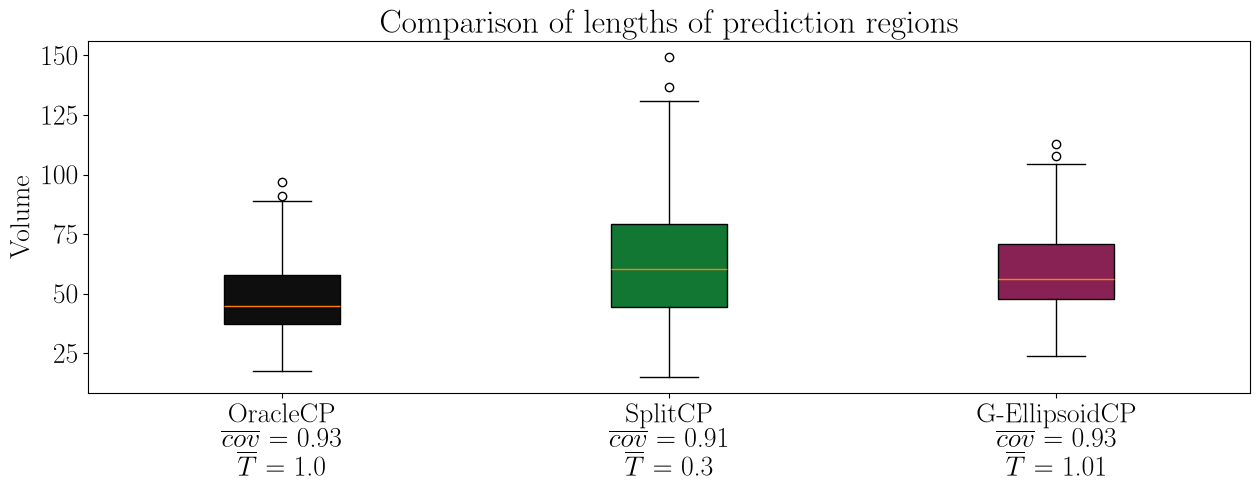

In [21]:
set_style()
CP_colors = ["#0E0E0E", "#117733", "#882255"]
for index, df_result in enumerate(df_results):
    fig = plot(df_result, CP_colors)
    fig.savefig(
        input_path + "prediction_region_volumes_{}_global".format(index) + ".eps",
        format="eps",
        bbox_inches="tight",
    )
    fig.savefig(
        input_path + "prediction_region_volumes_{}_global".format(index) + ".jpeg",
        format="jpeg",
        bbox_inches="tight",
    )

In [22]:
def plot_ratio(df_result, colors, shift):
    def labelize(name, df):

        cov = r"$\overline{cov}$ = "
        run_time = r"$\overline{T}$ = "
        mean_cov = str(np.round(df["coverage"].mean(), 2))
        mean_time = str(np.round(df["time"].mean(), 2))
        return name + " \n" + cov + mean_cov + " \n" + run_time + mean_time

    labels = []
    df_length = []
    for key in df_result.keys():
        if key != "OracleCP":
            if key == "GlobalEllipsoidCP":
                labels += [labelize("G-EllipsoidCP", df_result[key])]
            else:
                labels += [labelize(key, df_result[key])]
            df_length += [df_result[key]["length"] / df_result["OracleCP"]["length"]]

    fig, ax = plt.subplots(figsize=(13, 5))
    box = ax.boxplot(df_length, patch_artist=True)
    ax.set_ylabel(r"Volume relative to \textbf{OracleCP}'s")

    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)

    
    ax.plot(
        [1-shift, 2+shift], [1, 1], color="red"
    )

    ax.grid(False)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels)
    fig.tight_layout()
    # ax.set_title(r"Comparison of relative volumes of \textbf{OracleCP} of prediction regions")

    return fig

Failed to find a Ghostscript installation.  Distillation step skipped.


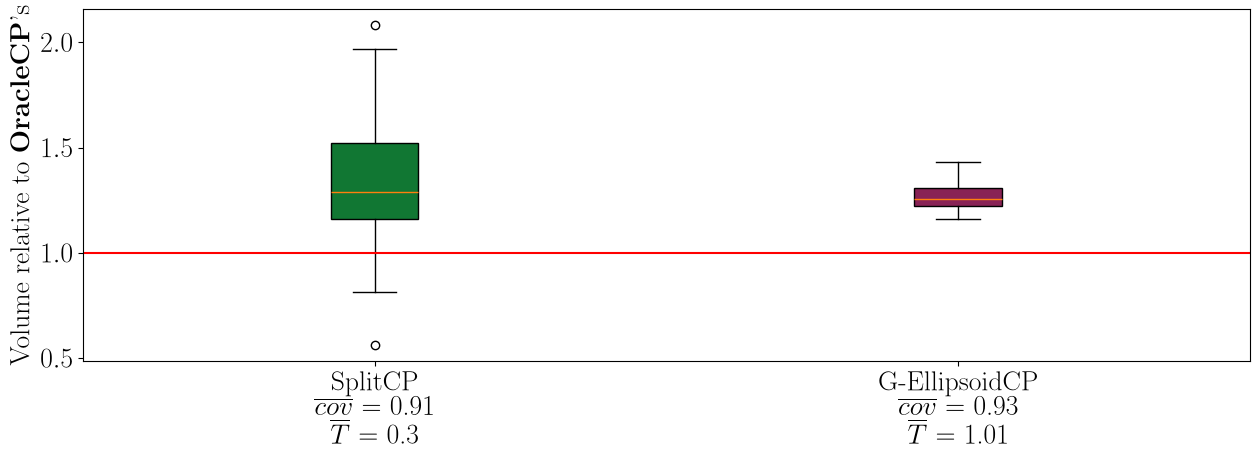

In [23]:
set_style()
CP_colors = [
#    "#0E0E0E",
    "#117733", "#882255"]
shift = 0.5
for index, df_result in enumerate(df_results):
    fig = plot_ratio(df_result, CP_colors, shift)
    fig.savefig(
        input_path + "prediction_region_relative_volumes_{}_global".format(index) + ".eps",
        format="eps",
        bbox_inches="tight",
    )
    fig.savefig(
        input_path + "prediction_region_relative_volumes_{}_global".format(index) + ".jpeg",
        format="jpeg",
        bbox_inches="tight",
    )